# KMeans



In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

from kmeans import KMeans

In [8]:
plt.style.use('default')

In [9]:
K:int = 3
N:int = 100
np.random.seed(1000)

In [10]:
random_points = np.random.randint(0, 100, (100, 2))

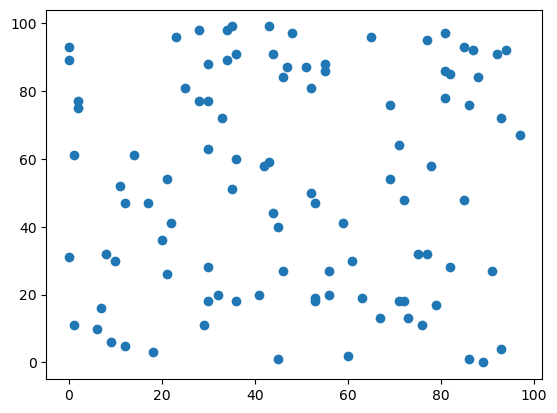

In [11]:
plt.style.use('default')
plt.scatter(random_points[:, 0], random_points[:, 1])

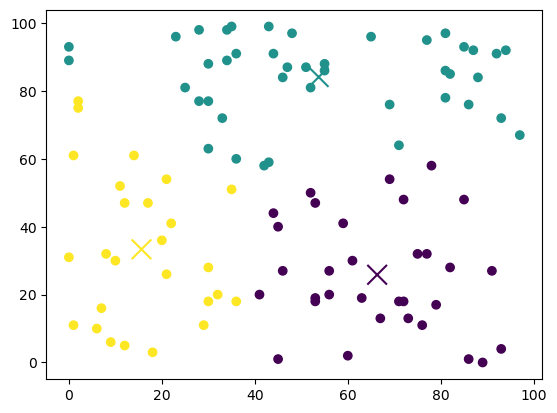

In [14]:
kmeans = KMeans(k=K, max_iters=100)
kmeans.fit(random_points, track_history=True)

# print(kmeans.centroids)
# print(kmeans.labels)
# print(kmeans.history)

plt.style.use('default')
plt.scatter(random_points[:, 0], random_points[:, 1], c=kmeans.labels, cmap='viridis')
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], c=range(len(kmeans.centroids)), marker='x', s=200, label='Centroids')
plt.show()


In [15]:

plt.style.use('default')

# Create a figure and axis for the animation
fig, ax = plt.subplots();  # Suppress the static plot output

# Initialize scatter plots for points and centroids
scatter_points = ax.scatter([], [], c=[], cmap='viridis', s=50)
scatter_centroids = ax.scatter([], [], c='red', marker='x', s=200, label='Centroids')

# Set axis limits based on the data
ax.set_xlim(np.min(random_points[:, 0]) - 10, np.max(random_points[:, 0]) + 10)
ax.set_ylim(np.min(random_points[:, 1]) - 10, np.max(random_points[:, 1]) + 10)
ax.legend()

# Update function for each frame in the animation
def update(frame):
    history_step = kmeans.history[frame]
    points_x, points_y, colors = [], [], []
    centroids_x, centroids_y = [], []

    for cluster_idx, (centroid, points) in enumerate(history_step.items()):
        centroids_x.append(centroid[0])
        centroids_y.append(centroid[1])
        if points.size > 0:  # Ensure points array is not empty
            points_x.extend(points[:, 0])
            points_y.extend(points[:, 1])
            colors.extend([cluster_idx] * len(points))

    scatter_points.set_offsets(np.c_[points_x, points_y])
    scatter_points.set_array(np.array(colors))
    scatter_centroids.set_offsets(np.c_[centroids_x, centroids_y])

    return scatter_points, scatter_centroids

# Create the animation
animation = FuncAnimation(fig, update, frames=len(kmeans.history), interval=500, blit=True)

plt.close(fig)  # Close the static plot to avoid displaying it

# Display the animation inline
HTML(animation.to_jshtml())


# Find the optimal number of clusters using the elbow method

The elbow method is a heuristic used in cluster analysis to determine the number of clusters in a dataset. It involves plotting the explained variation as a function of the number of clusters and selecting the "elbow" point where the rate of decrease sharply changes.

The computation of the elbow method involves the following steps:
1. **Fit the KMeans model**: For a range of cluster numbers (e.g., from 1 to 10), fit the KMeans model to the data.
2. **Calculate the inertia**: For each fitted model, calculate the inertia (sum of squared distances to the nearest cluster center).
3. **Plot the inertia**: Plot the inertia against the number of clusters.
4. **Identify the elbow point**: Look for the point where the inertia starts to decrease at a slower rate, indicating that adding more clusters does not significantly improve the model.

In [16]:
k_values = range(1, 13)

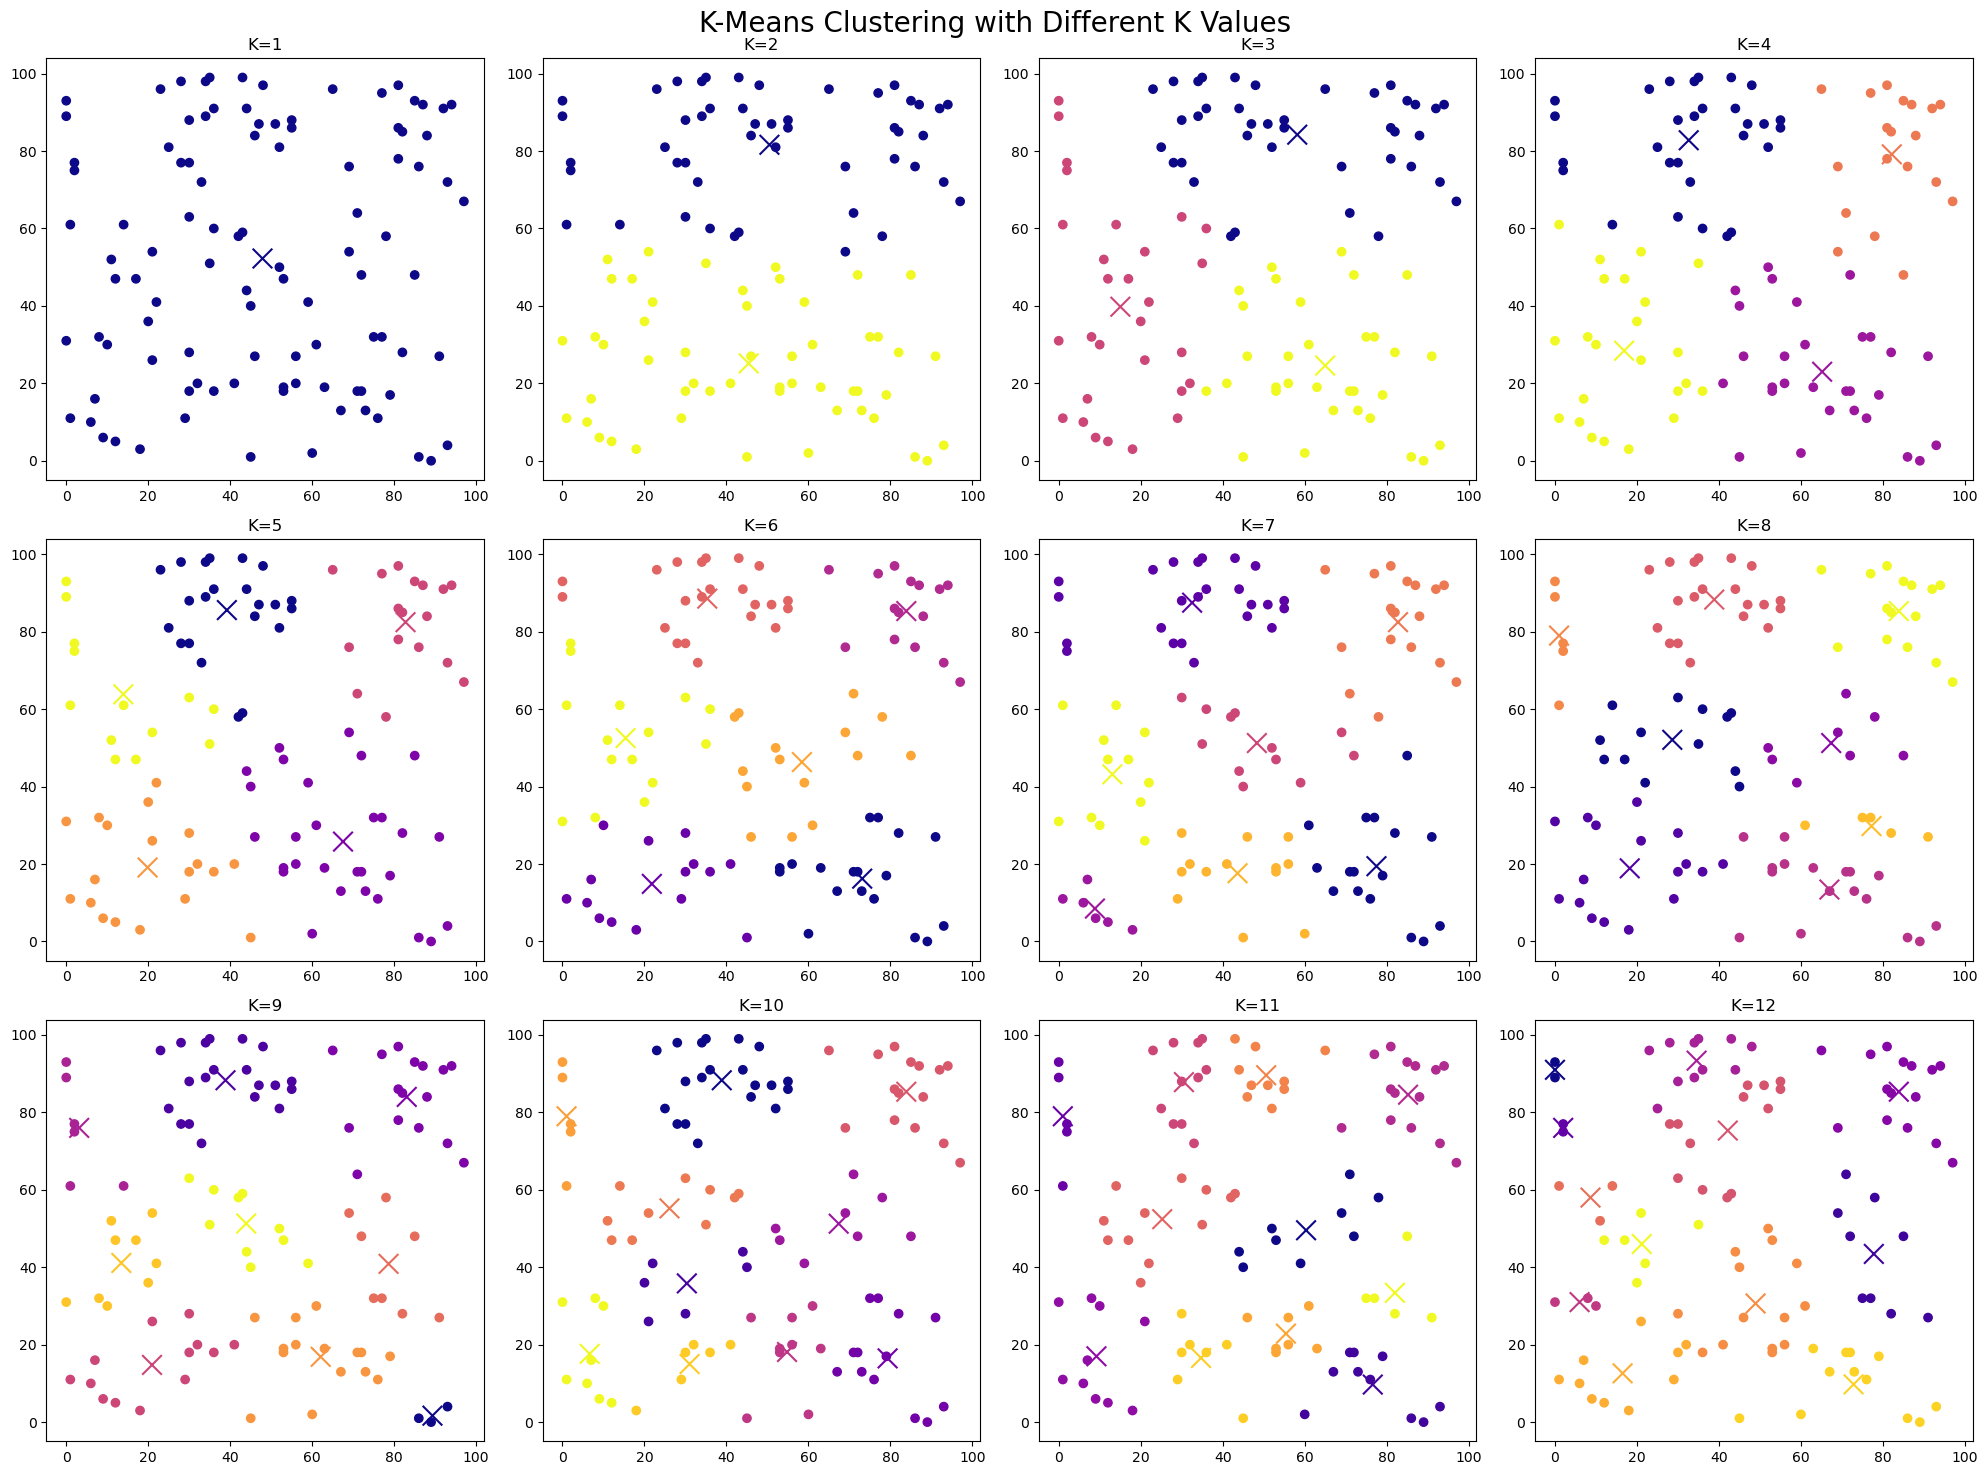

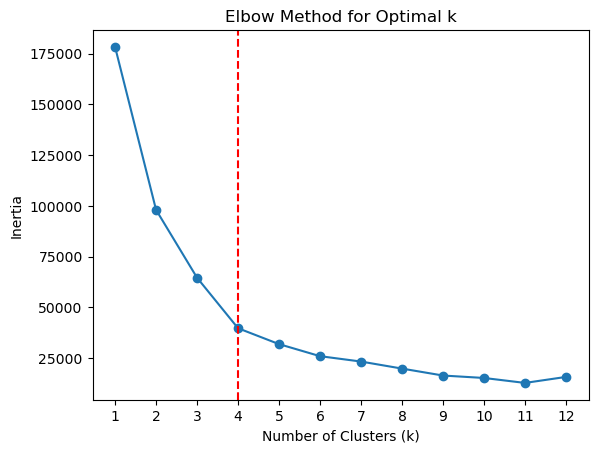

In [17]:
inertia = []

plt.style.use('default')
fig, ax = plt.subplots(3, 4, figsize=(20, 15))
fig.suptitle('K-Means Clustering with Different K Values', fontsize=20)
ax = ax.flatten()
for i, k in enumerate(k_values):
    kmeans = KMeans(k=k, max_iters=100)
    kmeans.fit(random_points)
    ax[i].scatter(random_points[:, 0], random_points[:, 1], c=kmeans.labels, cmap="plasma")
    ax[i].scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], c=range(len(kmeans.centroids)), cmap="plasma", marker='x', s=200, label='Centroids')
    ax[i].set_title(f'K={k}')

    # inertia computation
    # Calculate inertia (sum of squared distances to nearest centroid)
    total_inertia = 0
    for cluster in range(k):
        cluster_points = random_points[kmeans.labels == cluster]
        centroid = kmeans.centroids[cluster]
        total_inertia += np.sum(np.sum((cluster_points - centroid) ** 2, axis=1))
    inertia.append(total_inertia)
plt.tight_layout()
plt.show()
   

# Plot the elbow curve
plt.style.use('default')
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.axvline(x=4, color='r', linestyle='--', label='Optimal k')
plt.xticks(k_values)
plt.show()

## Generate Data using scikit-learn

In [19]:
from sklearn.datasets import make_blobs
#from sklearn.cluster import KMeans

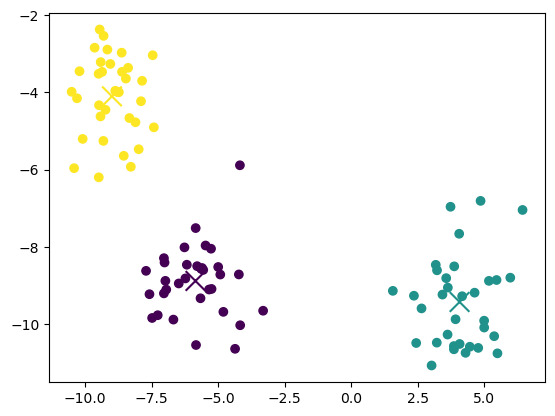

In [20]:
random_points, _ = make_blobs(n_samples=100, n_features=2, centers=K, random_state=21)
kmeans = KMeans(k=K, max_iters=100)
kmeans.fit(random_points)

# print(kmeans.centroids)
# print(kmeans.labels)
# print(kmeans.history)

plt.style.use('default')
plt.scatter(random_points[:, 0], random_points[:, 1], c=kmeans.labels, cmap='viridis')
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], c=range(len(kmeans.centroids)), marker='x', s=200, label='Centroids')
plt.show()
